In [5]:
import random
import numpy as np
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Global seed set to {SEED}")

Global seed set to 42


In [6]:
import polars as pl
import joblib
import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint



In [7]:

print("Loading Cleaned 1-Minute Data...")

file_path = "../cleanData/LSTM_Final_Cleaned_1m.csv"
df_final_1m = pl.read_csv(file_path)

print(f"Loaded Shape: {df_final_1m.shape}")
print(f"Columns: {df_final_1m.columns}")



Loading Cleaned 1-Minute Data...
Loaded Shape: (77700, 8)
Columns: ['msname', 'timestamp', 'total_cpu_demand', 'total_memory_demand', 'total_traffic', 'avg_node_stress', 'avg_response_time', 'replica_count']


In [8]:
print("Building sliding windows...")

WINDOW_SIZE = 5
features = ["total_traffic", "avg_node_stress", "total_cpu_demand"]

X_raw = []
y_raw = []

for name, group in df_final_1m.sort("timestamp").group_by("msname"):
    group_array = group.select(features).to_numpy()

    for i in range(WINDOW_SIZE, len(group_array)):
        X_raw.append(group_array[i-WINDOW_SIZE : i, :])
        y_raw.append(group_array[i, 2])

X_raw = np.array(X_raw)
y_raw = np.array(y_raw).reshape(-1, 1)

print(f"X_raw Shape: {X_raw.shape}")
print(f"y_raw Shape: {y_raw.shape}")

Building sliding windows...
X_raw Shape: (71225, 5, 3)
y_raw Shape: (71225, 1)


In [9]:
print("Splitting into Train/Validation sets...")

X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_raw, y_raw,
    test_size=0.2,
    shuffle=False
)

print(f"X_train_raw: {X_train_raw.shape} | X_val_raw: {X_val_raw.shape}")
print(f"y_train_raw: {y_train_raw.shape} | y_val_raw: {y_val_raw.shape}")

Splitting into Train/Validation sets...
X_train_raw: (56980, 5, 3) | X_val_raw: (14245, 5, 3)
y_train_raw: (56980, 1) | y_val_raw: (14245, 1)


In [10]:
print("Clipping outliers and scaling...")

CLIP_PERCENTILE = 99.5

# Clip y
y_clip_max = np.percentile(y_train_raw, CLIP_PERCENTILE)
print(f"Clipping CPU values above {y_clip_max:.4f} cores (p{CLIP_PERCENTILE})")

y_train_clipped = np.clip(y_train_raw, 0, y_clip_max)
y_val_clipped   = np.clip(y_val_raw,   0, y_clip_max)

# Clip X
X_clip_maxes = [
    np.percentile(X_train_raw[:, :, i], CLIP_PERCENTILE)
    for i in range(X_train_raw.shape[2])
]

X_train_clipped = X_train_raw.copy()
X_val_clipped   = X_val_raw.copy()

for i, clip_max in enumerate(X_clip_maxes):
    X_train_clipped[:, :, i] = np.clip(X_train_raw[:, :, i], 0, clip_max)
    X_val_clipped[:, :, i]   = np.clip(X_val_raw[:, :, i],   0, clip_max)

# Scale X
n_train, timesteps, n_features = X_train_clipped.shape

X_scaler = MinMaxScaler()
X_train_scaled = X_scaler.fit_transform(
    X_train_clipped.reshape(-1, n_features)
).reshape(n_train, timesteps, n_features)

X_val_scaled = X_scaler.transform(
    X_val_clipped.reshape(-1, n_features)
).reshape(X_val_clipped.shape)

# Scale y
y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train_clipped)
y_val_scaled   = y_scaler.transform(y_val_clipped)

joblib.dump(X_scaler, "v2_1m_X_scaler.pkl")
joblib.dump(y_scaler, "v2_1m_y_scaler.pkl")
print(f"Scaler saved. y range: {y_scaler.data_min_[0]:.4f} to {y_scaler.data_max_[0]:.4f} cores")

Clipping outliers and scaling...
Clipping CPU values above 259.4473 cores (p99.5)
Scaler saved. y range: 0.0058 to 259.4473 cores


In [11]:
print("Building LSTM Model...")

model = Sequential()
model.add(keras.Input(shape=(timesteps, n_features)))
model.add(LSTM(units=50, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse'
)
print(model.summary())

Building LSTM Model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,851 (42.39 KB)

 Trainable params: 10,851 (42.39 KB)

 Non-trainable params: 0 (0.00 B)

None


In [15]:
print("Starting Training...")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_lstm_model.keras",
    monitor='val_loss',
    save_best_only=True
)

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=50,
    batch_size=128,
    validation_data=(X_val_scaled, y_val_scaled),
    callbacks=[early_stop, checkpoint]
)

print("\nTraining Complete!")

Starting Training...
Epoch 1/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.7962e-04 - val_loss: 3.8768e-05
Epoch 2/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.6038e-04 - val_loss: 3.4555e-05
Epoch 3/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.5367e-04 - val_loss: 6.5938e-05
Epoch 4/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.4304e-04 - val_loss: 2.8003e-05
Epoch 5/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.5503e-04 - val_loss: 3.3576e-05
Epoch 6/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.3451e-04 - val_loss: 4.6943e-05
Epoch 7/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.4087e-04 - val_loss: 2.8062e-05
Epoch 8/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.4774e-04 - val_loss: 4.0828e-05
Epoch 9/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.4012e-04 - val_loss: 2.4309e-05
Epoch 10/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.3300e-04 - val_loss: 2.5047e-05
Epoch 11/50
446/446 ━━━━━━━━━━━━━━━━━━

In [16]:
sample_pred_scaled = model.predict(X_val_scaled[:5])
sample_pred_actual = y_scaler.inverse_transform(sample_pred_scaled)
sample_actual      = y_scaler.inverse_transform(y_val_scaled[:5])

print("\nSample Predictions vs Actual (CPU cores):")
print(f"{'Predicted':>12}  {'Actual':>12}  {'Difference':>12}")
print("-" * 40)
for pred, actual in zip(sample_pred_actual, sample_actual):
    diff = abs(pred[0] - actual[0])
    print(f"{pred[0]:>12.4f}  {actual[0]:>12.4f}  {diff:>12.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Sample Predictions vs Actual (CPU cores):
   Predicted        Actual    Difference
----------------------------------------
      1.7960        1.4402        0.3558
      1.8013        1.4418        0.3595
      1.8249        1.4558        0.3691
      1.8011        1.4487        0.3523
      1.8222        1.4518        0.3704


469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 955us/step
Mean Absolute Error:  0.5606 cores
Median Absolute Error: 0.4200 cores
Max Error:            20.5756 cores

Predicted range: 0.0882 to 232.7374
Actual range:    0.0071 to 231.5382


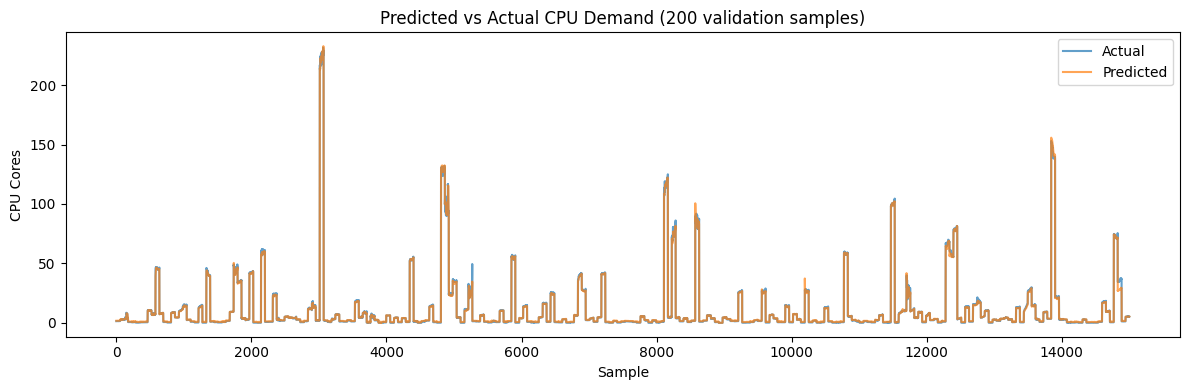

In [19]:
# Check 200 samples spread across the validation set
import matplotlib.pyplot as plt

n_check = 15000
indices = np.linspace(0, len(X_val_scaled)-1, n_check, dtype=int)

pred_scaled = model.predict(X_val_scaled[indices])
pred_actual = y_scaler.inverse_transform(pred_scaled)
true_actual = y_scaler.inverse_transform(y_val_scaled[indices])

# Print summary statistics
errors = np.abs(pred_actual - true_actual)
print(f"Mean Absolute Error:  {errors.mean():.4f} cores")
print(f"Median Absolute Error: {np.median(errors):.4f} cores")
print(f"Max Error:            {errors.max():.4f} cores")
print(f"\nPredicted range: {pred_actual.min():.4f} to {pred_actual.max():.4f}")
print(f"Actual range:    {true_actual.min():.4f} to {true_actual.max():.4f}")

# Plot predicted vs actual
plt.figure(figsize=(12, 4))
plt.plot(true_actual, label='Actual', alpha=0.7)
plt.plot(pred_actual, label='Predicted', alpha=0.7)
plt.xlabel('Sample')
plt.ylabel('CPU Cores')
plt.title('Predicted vs Actual CPU Demand (200 validation samples)')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on full validation set
n_val = len(X_val_scaled)
pred_scaled = model.predict(X_val_scaled)
pred_actual = y_scaler.inverse_transform(pred_scaled)
true_actual = y_scaler.inverse_transform(y_val_scaled)

# Calculate metrics
mae  = mean_absolute_error(true_actual, pred_actual)
rmse = np.sqrt(mean_squared_error(true_actual, pred_actual))
r2   = r2_score(true_actual, pred_actual)
mape = np.mean(np.abs((true_actual - pred_actual) / (true_actual + 1e-8))) * 100

print("=" * 40)
print("MODEL EVALUATION REPORT")
print("=" * 40)
print(f"MAE  (Mean Absolute Error):       {mae:.4f} cores")
print(f"RMSE (Root Mean Squared Error):   {rmse:.4f} cores")
print(f"R²   (Explained Variance):        {r2:.4f}")
print(f"MAPE (Mean Absolute % Error):     {mape:.2f}%")
print("=" * 40)

446/446 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step
MODEL EVALUATION REPORT
MAE  (Mean Absolute Error):       0.5611 cores
RMSE (Root Mean Squared Error):   1.0762 cores
R²   (Explained Variance):        0.9981
MAPE (Mean Absolute % Error):     94.39%
